# Detectability limit: the October 2023 Baltic storm surge

A worked example with the [`euroflood`](https://github.com/cisgroup/euroflood) package,
reproducing Section S1.7 (Fig. S7; main text Section 7.4) of the EuroFlood paper. Like the
Valencia DANA notebook, this is an honest look at a **temporal detectability limit** of the
source archive, this time for a coastal storm surge, where the water recedes quickly and a
satellite record can catch only delayed, residual inundation.

## The event

**Storm Babet** generated an exceptional Baltic storm surge along the Schleswig-Holstein coast
of Germany and the southern Danish coast on **20 to 21 October 2023** (surge peak 21 October).
Coastal water recedes rapidly after the peak, so this is a second test, after the Valencia DANA,
of whether the archive records the *maximum* flood extent or only what a later Sentinel-1
acquisition happened to see. HANZE documents the surge as two coastal events (a German and a
Danish component) affecting **2,140 people**, but reports no documented flood *area*, so unlike
Valencia there is no area-based capture ratio to compute; the evidence here is corroborating,
not an independent completeness estimate.

## The archive and the index

The observations come from the **CEMS-EFAS satellite-derived flood-depth maps** served through
`euroflood`'s **inverted raster index**. Access is two-stage: **Discover** with `floods(...)`
returning a `FloodFrame` (a `geopandas.GeoDataFrame`), then **Extract** native 20 m depth with
`download()`. This case uses **region-clipped** queries (an exact administrative boundary rather
than a bounding box) and, being a coastal surge, makes no modelled-hazard comparison (CEMS-GLOFAS
is fluvial only).

> Runs against `euroflood >= 0.2.0` with the `viz` extra, querying the published index
> (needs network on first use, or a locally mirrored index).

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown

import euroflood as ef

import _support as S

## The documented regions

We take the documented domain from HANZE: the two October 2023 coastal rows for Germany and
Denmark give the affected population and the NUTS level 3 regions. We union those regions (from
the committed GISCO layer) so the satellite measurement and the documentary record refer to the
same ground.

In [2]:
hanze = pd.read_csv(S.DATA / "hanze" / "HANZE_events_v3_0_1b.csv")
region_col = "Regions affected (NUTS 3)"
babet = hanze[
    (hanze["Year"] == 2023)
    & (hanze["Type"] == "Coastal")
    & (hanze["Country code"].isin(["DE", "DK"]))
    & (hanze["Start date"].astype(str).str.startswith("2023-10"))
]
codes = sorted({c.strip() for row in babet[region_col] for c in str(row).split(";") if c.strip()})
affected = int(babet["Persons affected"].sum())
print(f"HANZE coastal rows: {len(babet)} (DE + DK) · {affected:,} people affected")
print(f"documented NUTS-3 regions ({len(codes)}): {codes}")

nuts = gpd.read_file(S.DATA / "gisco" / "nuts_20m_2024.geojson")
regions = nuts[(nuts["LEVL_CODE"] == 3) & (nuts["NUTS_ID"].isin(codes))].dissolve()

HANZE coastal rows: 2 (DE + DK) · 2,140 people affected
documented NUTS-3 regions (9): ['DE80L', 'DEF02', 'DEF08', 'DEF0B', 'DEF0C', 'DK021', 'DK022', 'DK031', 'DK032']


## The archive cluster (context, not the surge)

A wide query over the German and Danish Baltic coast shows how the archive bundles observations.
The matched Storm Babet record is part of a much larger source-file cluster that also combines
North Sea coastal and inland flooding: within the wide window it indexes about **384 km<sup>2</sup>**.
This is context for the archive's cluster semantics, not the surge itself.

In [3]:
cluster = ef.floods(bbox=(6.0, 53.0, 16.0, 59.0), start="2023-10-18", end="2023-11-05")
cluster_km2 = float(cluster.footprints()["extent_km2"].sum())
print(f"wide-window Babet cluster: {len(cluster)} archive files, {cluster_km2:.1f} km2 indexed extent")

wide-window Babet cluster: 2 archive files, 383.8 km2 indexed extent


## Discover over the documented regions

Now we query only the documented coast, clipping exactly to the region union with `shape="exact"`.
The archive holds a single surge-relevant acquisition (30 October) plus other autumn events.

In [4]:
season = ef.floods(regions, start="2023-10-05", end="2023-11-30", shape="exact")
print(f"{len(season)} archive files across dates: {sorted(season['date'].astype(str).unique())}")
season.explore(footprints=True, tiles="grayscale")

4 archive files across dates: ['2023-10-09', '2023-10-30', '2023-11-27']


## The surge capture

Because the query used `shape="exact"`, `download()` crops each raster to the documented regions,
so `.stats()` reports the in-region detected area directly. The **30 October** acquisition, nine
days after the surge peak, is the surge-relevant capture.

In [5]:
dl = season.download(str(S.ROOT / "out" / "baltic_notebook"))
stats = dl.stats()
stats["date"] = stats["date"].astype(str)
by_date = stats.groupby("date")["flooded_area_km2"].sum().round(1)
by_date.to_frame("in_region_km2")

,in_region_km2
date,
2023-10-09,23.5
2023-10-30,54.5
2023-11-27,52.2


In [6]:
surge_km2 = float(by_date["2023-10-30"])
# the 30 Oct surge is two files (a main capture and a near-empty sliver); the p95 of the
# main file is the representative depth.
surge_p95 = float(stats[stats["date"] == "2023-10-30"].nlargest(1, "flooded_area_km2")["p95_depth_m"].iloc[0])
print(f"surge capture (30 Oct, within documented regions): {surge_km2:.1f} km2")
print(f"detected depth 95th percentile: {surge_p95:.2f} m (predominantly shallow, residual water)")
print("first surge-relevant acquisition 30 Oct, 9 days after the 21 Oct peak")

surge capture (30 Oct, within documented regions): 54.5 km2
detected depth 95th percentile: 0.58 m (predominantly shallow, residual water)
first surge-relevant acquisition 30 Oct, 9 days after the 21 Oct peak


## Zoom in: the delayed residual water

The single 30 October acquisition as a `DepthRaster` on the grey basemap. The detected water is
thin and fragmented, consistent with an observation made after the surge had largely drained.

In [7]:
surge = dl[dl["date"] == "2023-10-30"].nlargest(1, "area_km2")
ef.open_depth(surge["path"].iloc[0]).explore(tiles="grayscale", vmax=1.0)

## Single acquisition, composite, and cluster

Three very different areas describe this event, and it matters not to confuse them. A
**multi-event autumn composite** (the per-cell maximum depth across the four archive files
between 9 October and 27 November) covers about **84 km<sup>2</sup>** within the documented
regions (reported in the paper); it is not a single simultaneous flood surface. The single
surge acquisition (54.5 km<sup>2</sup>) is a lower bound, and the wide cluster (384 km<sup>2</sup>)
bundles hydrologically distinct flooding across the whole region.

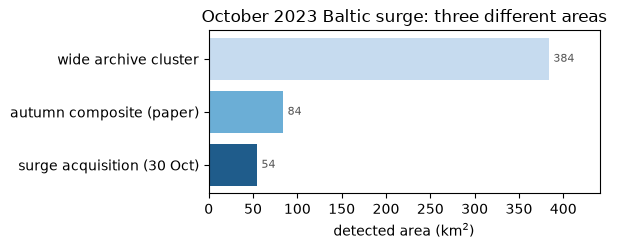

In [8]:
scales = {
    "surge acquisition (30 Oct)": surge_km2,
    "autumn composite (paper)": 84.0,
    "wide archive cluster": cluster_km2,
}
fig, ax = plt.subplots(figsize=(6.2, 2.6))
ax.barh(list(scales), list(scales.values()), color=["#1f5c8b", "#6baed6", "#c6dbef"])
ax.set_xlabel("detected area (km$^2$)")
ax.set_title("October 2023 Baltic surge: three different areas")
for i, v in enumerate(scales.values()):
    ax.text(v + 5, i, f"{v:,.0f}", va="center", fontsize=8, color="#555555")
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

In [9]:
# Key figures, computed from the cells above.
Markdown(
    f"### Key figures\n"
    f"| | |\n|---|---|\n"
    f"| **Surge capture within documented regions (30 Oct)** | **{surge_km2:.1f} km²** |\n"
    f"| **Lag from surge peak (21 Oct) to first acquisition** | **9 days** |\n"
    f"| **Detected depth 95th percentile** | **{surge_p95:.2f} m** |\n"
    f"| **Multi-event autumn composite (paper)** | **84 km²** |\n"
    f"| **Wide archive cluster extent** | **{cluster_km2:.0f} km²** |\n"
    f"| **People affected (HANZE, DE + DK)** | **{affected:,}** |\n"
)

### Key figures
| | |
|---|---|
| **Surge capture within documented regions (30 Oct)** | **54.5 km²** |
| **Lag from surge peak (21 Oct) to first acquisition** | **9 days** |
| **Detected depth 95th percentile** | **0.58 m** |
| **Multi-event autumn composite (paper)** | **84 km²** |
| **Wide archive cluster extent** | **384 km²** |
| **People affected (HANZE, DE + DK)** | **2,140** |


## The published figure

The paper's Fig. S7 (the dated autumn events over the wider coast, the maximum reconstructed
depth within the documented regions with its shallow-depth histogram, and the surge summary and
timeline) is assembled by the paper's figure script, shown here for comparison.

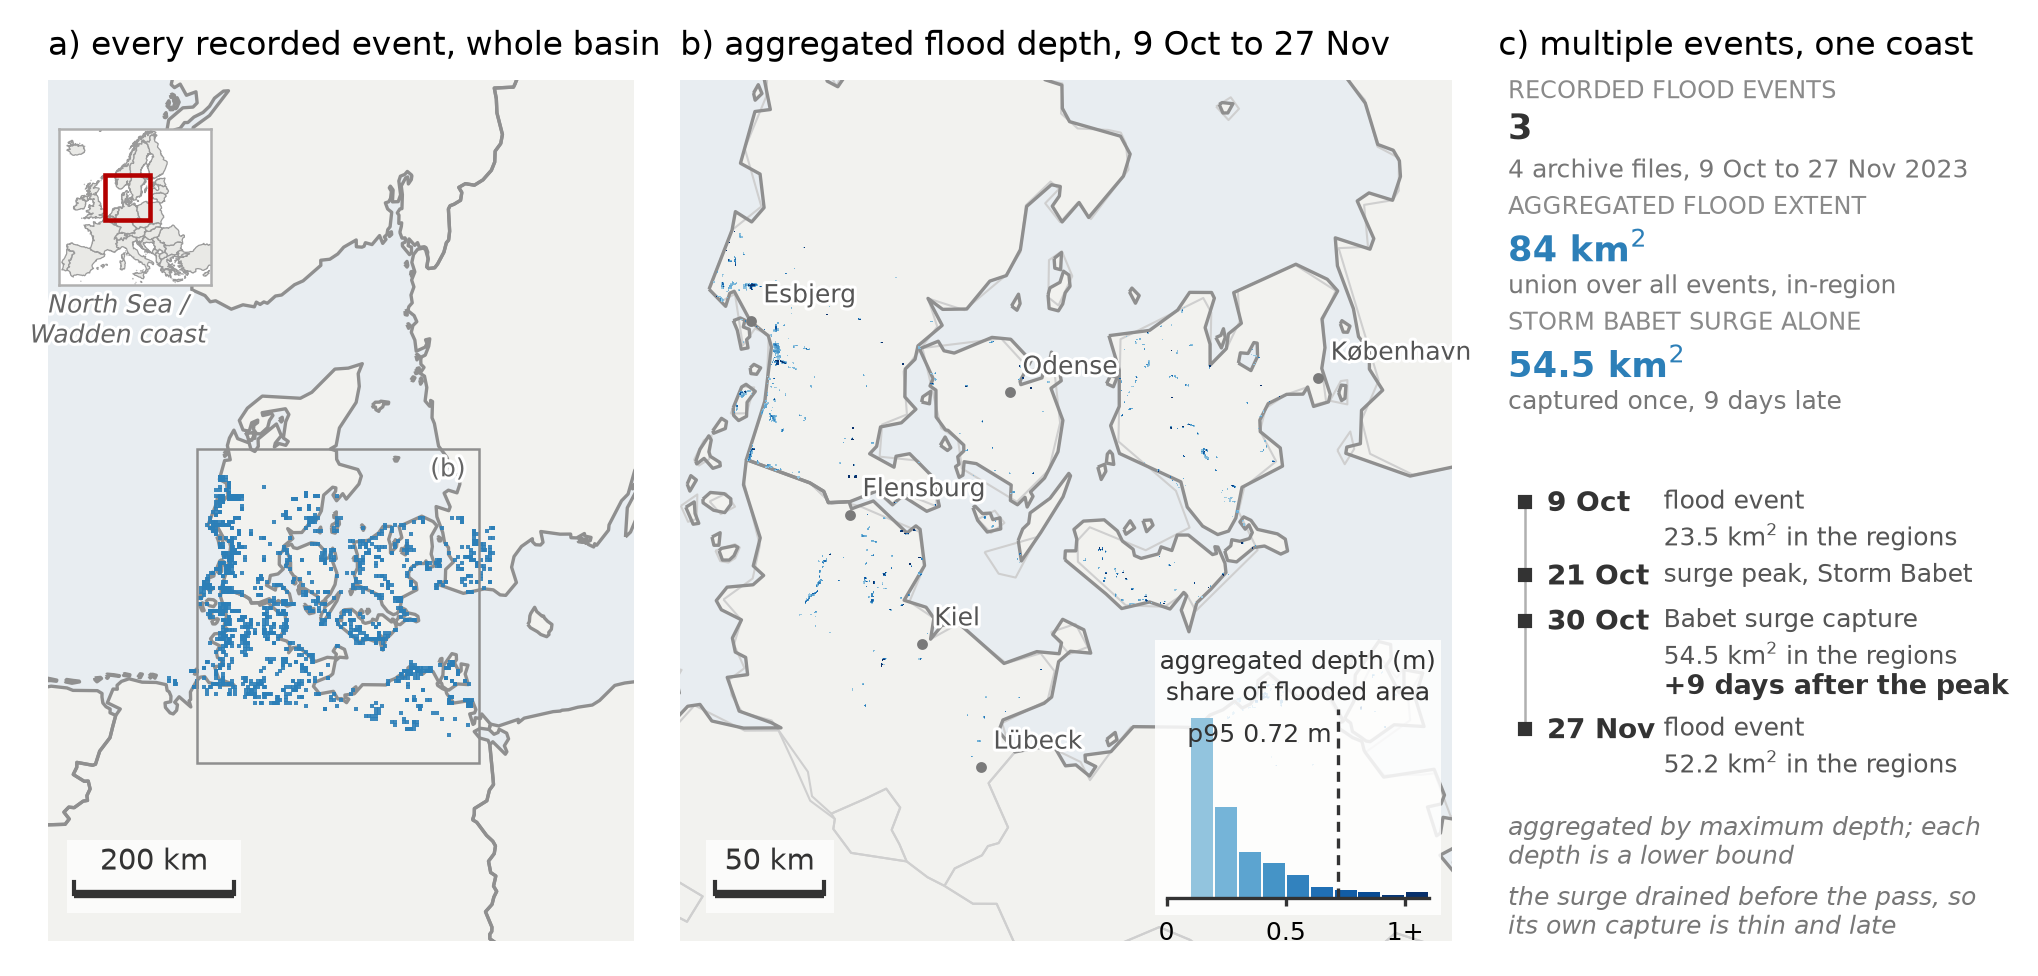

In [10]:
S.published_figure("baltic")

## Interpretation

The archive captures the surge only once, nine days late, as shallow residual water. Reading it
well means keeping three things separate:

1. **A single acquisition is not the peak.** The 30 October capture records delayed residual
   inundation, a lower bound, not the maximum surge extent.
2. **A composite is not a snapshot.** The 84 km<sup>2</sup> autumn composite is a per-cell
   maximum over several acquisitions weeks apart, not a simultaneous flood surface.
3. **A documented event is not an archive cluster.** HANZE's coastal surge is one thing; the
   384 km<sup>2</sup> source-file cluster bundles North Sea and inland flooding too.

Because HANZE reports no documented area for this surge, the evidence is *corroborating* (the
archive is consistent with a fast-draining coastal event) rather than an independent estimate of
completeness. As with the Valencia DANA, a small or absent footprint does not imply a small flood.

## References and reuse

This notebook reproduces the Baltic storm-surge case study (Supplementary Material, Section S1.7,
Fig. S7; main text Section 7.4) of:

> J. Hackl (2026). *EuroFlood: a Python library and queryable index for the CEMS
> satellite-derived flood-depth archive of Europe.*